# tRIBS-Sandbox: Run Model

The goal for this notebook is to first run the model we made then use pytRIBS to load in our model outputs and make some plots from the model outputs. The plots shown below are just examples and each output file has multiple variables that can be plotted. Addtion detail on the available model outputs is located [Here](https://tribshms.readthedocs.io/en/latest/man/Output.html)

## Imports

In [9]:
# note you can install pytRIBS via pip; see: https://pypi.org/project/pytRIBS/
from pytRIBS.classes import *

In [10]:
# if you have installed pytRIBS, the following libraries should already be in your environment
import os, sys, shutil
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from shapely.ops import unary_union
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors

### Run The Model
In our previous notebook we got everything organized to run the model. Typically tRIBS is ran from the command line but in this codespace we setup a direct path to the tRIBS executeable so we run the executeable from within this notebook. 

So lets run the simulation:

In [11]:
import time

# Define File Names
input_filename = 'SMF_100yr.in'  
log_filename   = 'simulation.log'

# Pre-run check
# Check if the input file actually exists before trying to run.
if not os.path.exists(input_filename):
    print(f"ERROR: Could not find input file: '{input_filename}'")
    print("Please check your spelling or ensure the previous pytRIBS step ran correctly.")
else:
    print(f"Found input file: {input_filename}")
    print(f"Starting tRIBS simulation...")
    print(f"Runtime output is being redirected to: {log_filename}")

    # Execute model
    # We use the 'time' module to track how long the simulation takes.
    start_time = time.time()
    
    # Run tRIBS! 
    # syntax: !tRIBS <input_file> > <log_file> 2>&1
    exit_code = os.system(f"tRIBS {input_filename} > {log_filename} 2>&1")
    
    end_time = time.time()
    duration = (end_time - start_time) / 60

    # Post-run report
    if exit_code == 0:
        print(f"\nSUCCESS: Simulation completed in {duration:.2f} minutes.")

Found input file: SMF_100yr.in
Starting tRIBS simulation...
Runtime output is being redirected to: simulation.log

SUCCESS: Simulation completed in 0.10 minutes.


## Results Class: Merge and Visualize Results
The Results class simplifies working with tRIBS outputs by offering post-processing methods that handle everything from file management to basic model output analysis. tRIBS generates a large amount of data with fine spatial and temporal resolutions, including time series of streamflow and spatially averaged state and flux variables. Additionally, the model produces Voronoi diagrams that can be used with both dynamic snapshots (captured at specific times) and integrated outputs (aggregated over the entire model run). The Results class helps manage these outputs, providing users with tools to merge parallel results and perform further analysis using commonly utilized data libraries.

In [12]:
name ='SMF_100yr'
epsg = 26912
proj = Project(os.getcwd(),name,epsg) 
# With this command below pytRIBS will read the input file to ge tthe filepaths of all output locations
results = Results('SMF_100yr.in',meta=proj.meta)

In [13]:
gdf = results.voronoi.merge(results.int_spatial_vars,on='ID')
results.get_mrf_results()
results.get_element_results()

strmflw_sim_raw = results.get_qout_results()
mrf = results.mrf['mrf']
mrf.set_index('Time',inplace=True)

Reading in: SMF_continuous1547.pixel
Reading in: SMF_continuous1960.pixel
Reading in: SMF_100yr3082.pixel
Reading in: SMF_100yr1547.pixel
Reading in: SMF_continuous3082.pixel
Reading in: SMF_100yr1960.pixel


### Visualize Results
First lets start with plotting the tRIBS outlet streamflow timeseries and compare it to the observations. Our ouputs and obervational data are not in the same time intervals so we need to do some preprocessing first.

/tmp/ipykernel_4750/841339473.py:11: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  sim_resampled = strmflw_sim['Qstrm_m3s'].resample('5T').mean()


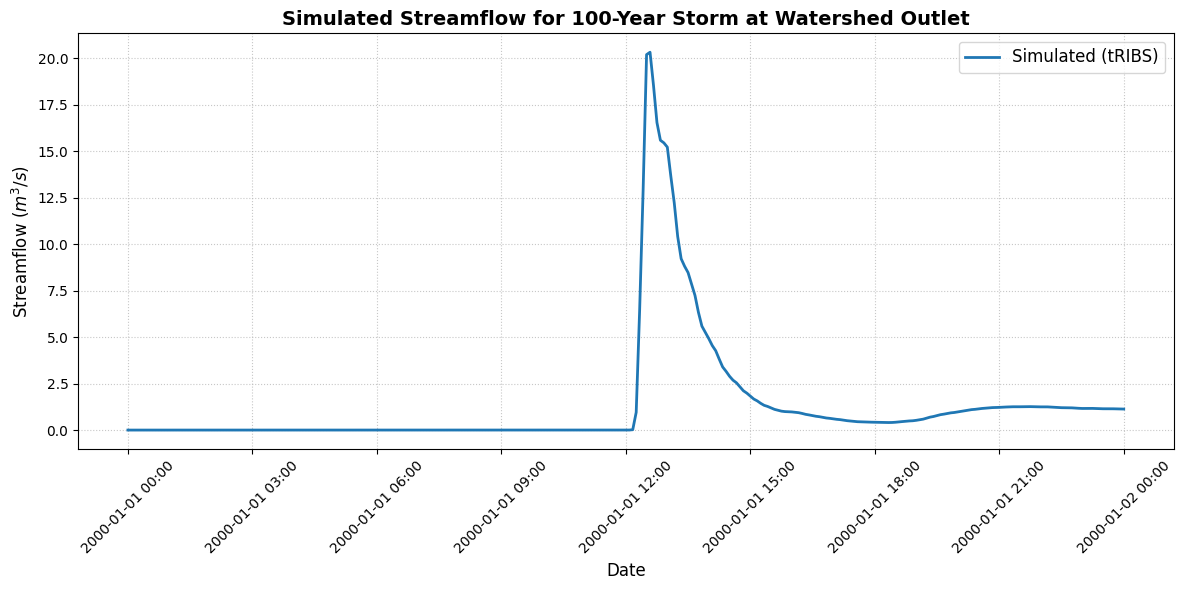

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# PREPARE SIMULATED DATA TIMESERIES
strmflw_sim = strmflw_sim_raw.copy()
strmflw_sim['Time'] = pd.to_datetime(strmflw_sim['Time'])
strmflw_sim.set_index('Time', inplace=True)

# OPTIONAL: resample to 5-minute averages to match original workflow style
sim_resampled = strmflw_sim['Qstrm_m3s'].resample('5T').mean()

# Put into a dataframe like the original workflow
storm_df = pd.DataFrame({
    'Simulated': sim_resampled
}).dropna()

# Define the storm window
event_start = storm_df.index.min()
event_end = storm_df.index.max()
event_df = storm_df.loc[event_start:event_end]

# PLOTTING THE HYDROGRAPH
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    event_df.index,
    event_df['Simulated'],
    label='Simulated (tRIBS)',
    color='#1f77b4',
    linewidth=2
)

# Formatting the plot
ax.set_title('Simulated Streamflow for 100-Year Storm at Watershed Outlet',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Streamflow ($m^3/s$)', fontsize=12)
ax.set_xlabel('Date', fontsize=12)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
plt.xticks(rotation=45)

ax.legend(fontsize=12)
ax.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

Now that we have orgnaized and plotted our streamflow data we can look at some preformance metrics

In [22]:
import numpy as np
import pandas as pd

# Make sure we are using the clipped storm event dataframe!
sim = event_df['Simulated']

# PHYSICAL EVENT METRICS
# Peak Discharge (m^3/s)
sim_peak = sim.max()

# Time to Peak
sim_tpeak = sim.idxmax()

# Total Volume (m^3)
dt_seconds = (event_df.index[1] - event_df.index[0]).total_seconds()
sim_vol_m3 = sim.sum() * dt_seconds

# Additional simple event timing metrics
if (sim > 0).any():
    sim_first_flow = sim[sim > 0].index.min()
    sim_last_flow = sim[sim > 0].index.max()
    sim_duration_hr = (sim_last_flow - sim_first_flow).total_seconds() / 3600.0
    sim_rise_time_hr = (sim_tpeak - sim_first_flow).total_seconds() / 3600.0
else:
    sim_first_flow = pd.NaT
    sim_last_flow = pd.NaT
    sim_duration_hr = np.nan
    sim_rise_time_hr = np.nan

# Print a Simple Report
print("--- 100-YEAR STORM HYDROLOGICAL METRICS ---")
print(f"Simulated Peak Flow: {sim_peak:.2f} m^3/s  (at {sim_tpeak.strftime('%m-%d %H:%M')})")
print(f"Simulated Volume:    {sim_vol_m3:,.0f} m^3")

if pd.notna(sim_first_flow):
    print(f"First Flow Time:     {sim_first_flow.strftime('%m-%d %H:%M')}")
    print(f"Flow Duration:       {sim_duration_hr:.2f} hours")
    print(f"Rise Time:           {sim_rise_time_hr:.2f} hours")

--- 100-YEAR STORM HYDROLOGICAL METRICS ---
Simulated Peak Flow: 20.33 m^3/s  (at 01-01 12:35)
Simulated Volume:    113,773 m^3
First Flow Time:     01-01 12:05
Flow Duration:       11.92 hours
Rise Time:           0.50 hours


tRIBS has many model outputs. One of those is spatial outputs. For this sandbox environment the integrated spatial output file has outputs like time invariant watershed properties but also cumulative outputs of flux variable like evapotranspiration.

First spatial plot we will make is the voronoi polygon elevation map:

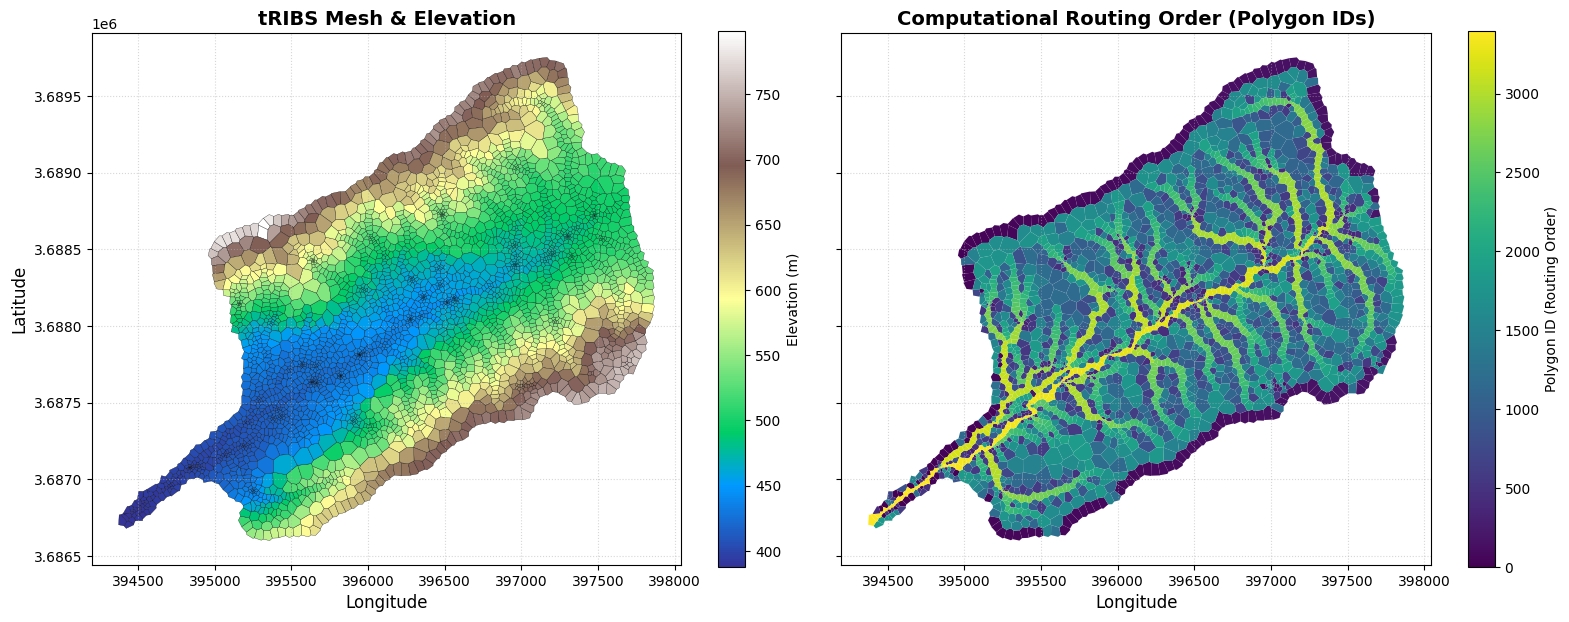

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Left PLOT: Elevation and Mesh Structure ---
gdf.plot(ax=ax1, column='Z', cmap='terrain', 
         edgecolor='black', linewidth=0.2,
         legend=True, legend_kwds={'label': 'Elevation (m)', 'shrink': 0.8})

ax1.set_title('tRIBS Mesh & Elevation', fontsize=14, fontweight='bold')
ax1.set_xlabel('Longitude', fontsize=12)
ax1.set_ylabel('Latitude', fontsize=12)
ax1.grid(True, linestyle=':', alpha=0.5)

# rightPLOT: Polygon ID
gdf.plot(ax=ax2, column='ID', cmap='viridis', 
         edgecolor='none', 
         legend=True, legend_kwds={'label': 'Polygon ID (Routing Order)', 'shrink': 0.8})

ax2.set_title('Computational Routing Order (Polygon IDs)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Longitude', fontsize=12)
ax2.set_yticklabels([]) 
ax2.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

Notice in the plot above how the lower Voronoi polygon ID values are all along the ridgeline boundary and the channels all have high values. This is how tRIBS assign the ID values, lower values are computed first i.e. they don't have an upstream neighbor that is giving them water.

Next we can plot the cumulative ET for the entire 480 hour simulaiton

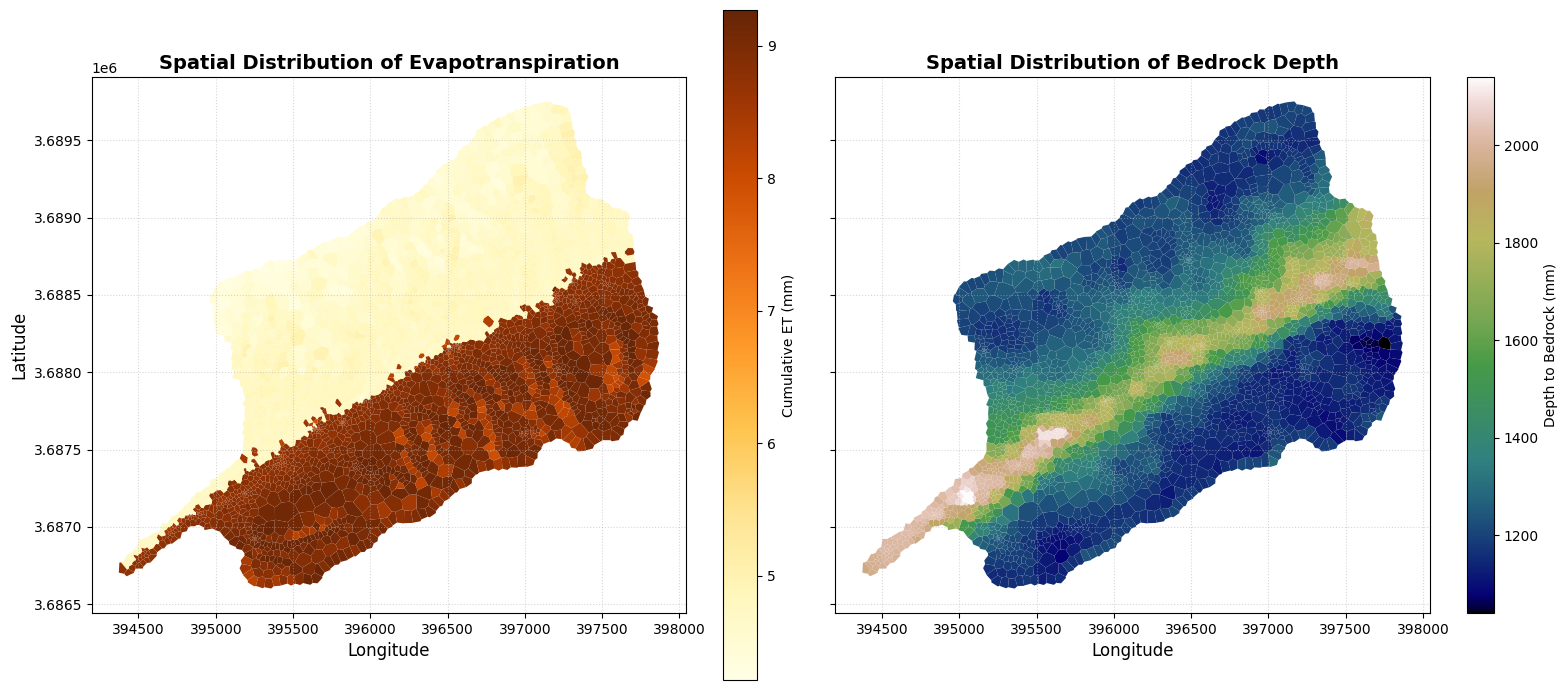

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Left PLOT: ET
gdf.plot(ax=ax1, column='cET', cmap='YlOrBr', legend=True,
         edgecolor='none', 
         legend_kwds={'label': 'Cumulative ET (mm)', 'orientation': 'vertical'})

ax1.set_title('Spatial Distribution of Evapotranspiration', fontsize=14, fontweight='bold')
ax1.set_xlabel('Longitude', fontsize=12)
ax1.set_ylabel('Latitude', fontsize=12) 
ax1.grid(True, linestyle=':', alpha=0.5)

# rightPLOT: Depth to Bedrock
gdf.plot(ax=ax2, column='Bedrock_Depth_mm', cmap='gist_earth', 
         edgecolor='none', 
         legend=True, legend_kwds={'label': 'Depth to Bedrock (mm)', 'shrink': 0.8})

ax2.set_title('Spatial Distribution of Bedrock Depth', fontsize=14, fontweight='bold')
ax2.set_xlabel('Longitude', fontsize=12)
ax2.set_yticklabels([]) 
ax2.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

Interestingly the model has some pretty large differences in cumulative ET. The plot of depth to bedrock was added as one way of getting to an explanation. Since the soils are so shallow on the mountainous slopes the vegetation in those areas has full access to any soil water available.

Another coomonly used model output is the mean response file (`*.mrf`). This output is a timeseries of many of the model's important variables. In the plot below we include the 

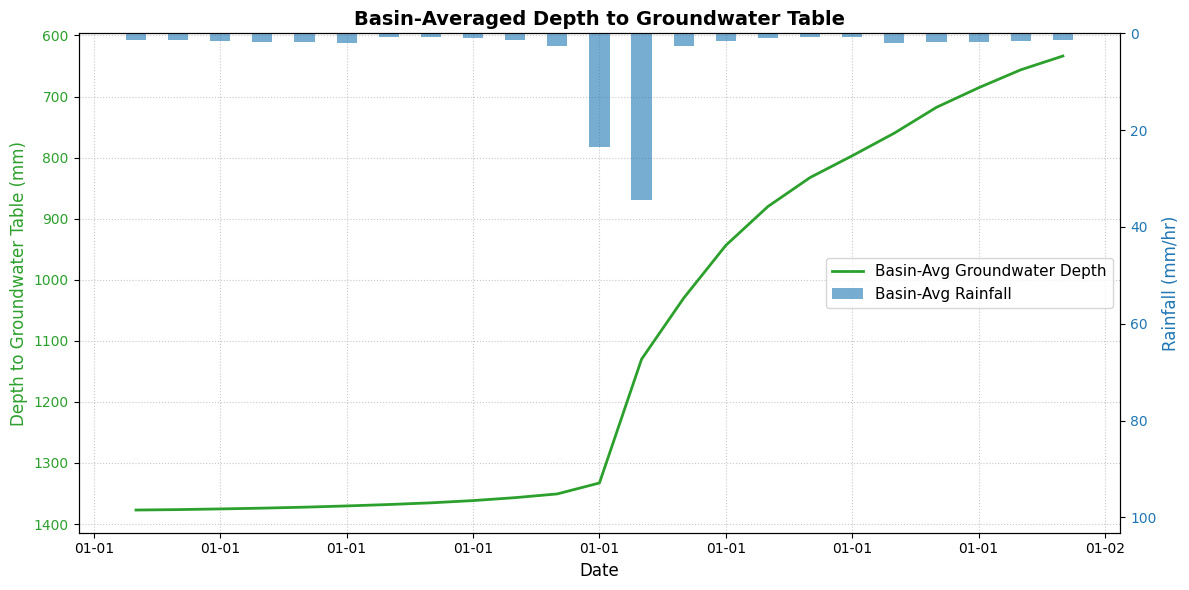

In [18]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax1 = plt.subplots(figsize=(12, 6))

# Bottom AXIS: Depth to Groundwater Table 
ax1.plot(mrf.index, mrf['MDGW'], color='#2ca02c', linewidth=2, label='Basin-Avg Groundwater Depth')

ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Depth to Groundwater Table (mm)', fontsize=12, color='#2ca02c')
ax1.tick_params(axis='y', labelcolor='#2ca02c')

# Lets invert the Y-axis so we can see the depth increase as the watertable is drawn down
ax1.invert_yaxis() 

# Top AXIS: Rainfall Hyetograph
ax2 = ax1.twinx()

ax2.bar(mrf.index, mrf['MAP'], width=0.02, color='#1f77b4', alpha=0.6, label='Basin-Avg Rainfall')

ax2.set_ylabel('Rainfall (mm/hr)', fontsize=12, color='#1f77b4')
ax2.tick_params(axis='y', labelcolor='#1f77b4')
ax2.invert_yaxis()

# Set limits so the rainfall bars only take up the top 30% of the plot
max_rain = mrf['MAP'].max()
ax2.set_ylim(max_rain * 3, 0) 

# Formatting
ax1.set_title('Basin-Averaged Depth to Groundwater Table', fontsize=14, fontweight='bold')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax1.grid(True, linestyle=':', alpha=0.7)

# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right', fontsize=11)

plt.tight_layout()
plt.show()




Here we plotted to the groundwater depth from mrf file only the lower axis and mean areal precipitation on the top axis. We can see with the shallow depth to bedrock the soil is almost instantly saturated.

/tmp/ipykernel_4750/3733919828.py:9: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  sim_resampled = strmflw_sim['Qstrm_m3s'].resample('5T').mean()


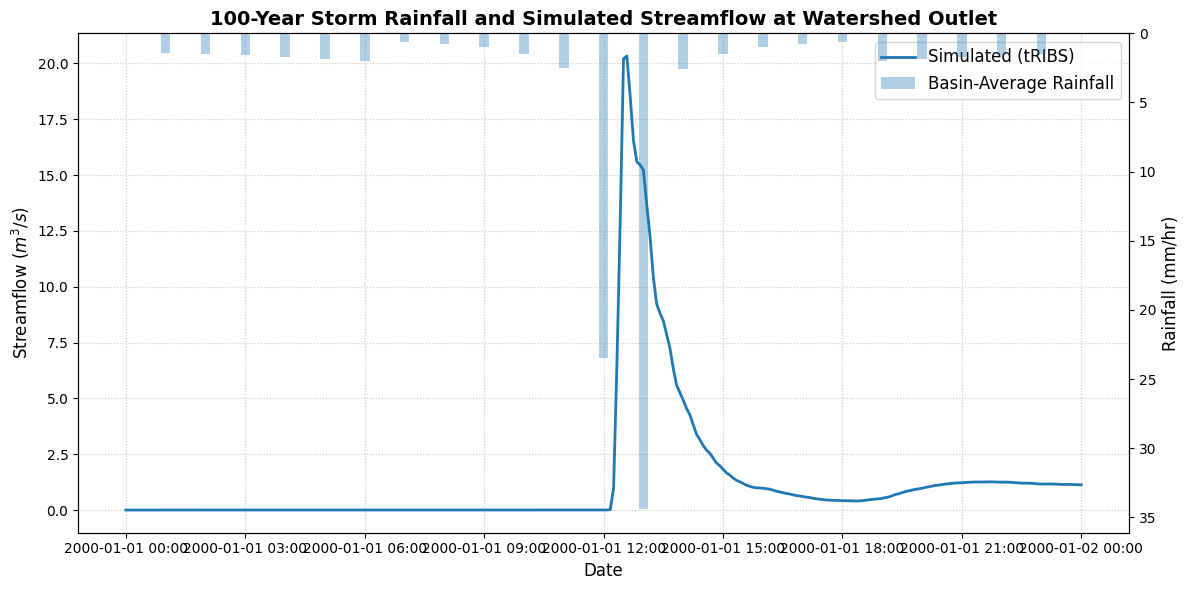

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# PREPARE SIMULATED DATA
strmflw_sim = strmflw_sim_raw.copy()
strmflw_sim['Time'] = pd.to_datetime(strmflw_sim['Time'])
strmflw_sim.set_index('Time', inplace=True)
sim_resampled = strmflw_sim['Qstrm_m3s'].resample('5T').mean()

storm_df = pd.DataFrame({
    'Simulated': sim_resampled
}).dropna()

event_start = storm_df.index.min()
event_end = storm_df.index.max()
event_df = storm_df.loc[event_start:event_end]

# PREPARE RAINFALL
mrf_plot = mrf.copy()
mrf_plot.index = pd.to_datetime(mrf_plot.index)
rain_df = mrf_plot.loc[event_start:event_end]

# PLOTTING
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(
    event_df.index,
    event_df['Simulated'],
    label='Simulated (tRIBS)',
    color='#1f77b4',
    linewidth=2
)
ax1.set_title('100-Year Storm Rainfall and Simulated Streamflow at Watershed Outlet',
              fontsize=14, fontweight='bold')
ax1.set_ylabel('Streamflow ($m^3/s$)', fontsize=12)
ax1.set_xlabel('Date', fontsize=12)

ax2 = ax1.twinx()
ax2.bar(
    rain_df.index,
    rain_df['MAP'],
    width=0.01,
    alpha=0.35,
    label='Basin-Average Rainfall'
)
ax2.set_ylabel('Rainfall (mm/hr)', fontsize=12)
ax2.invert_yaxis()

ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
plt.xticks(rotation=45)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=12, loc='upper right')

ax1.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

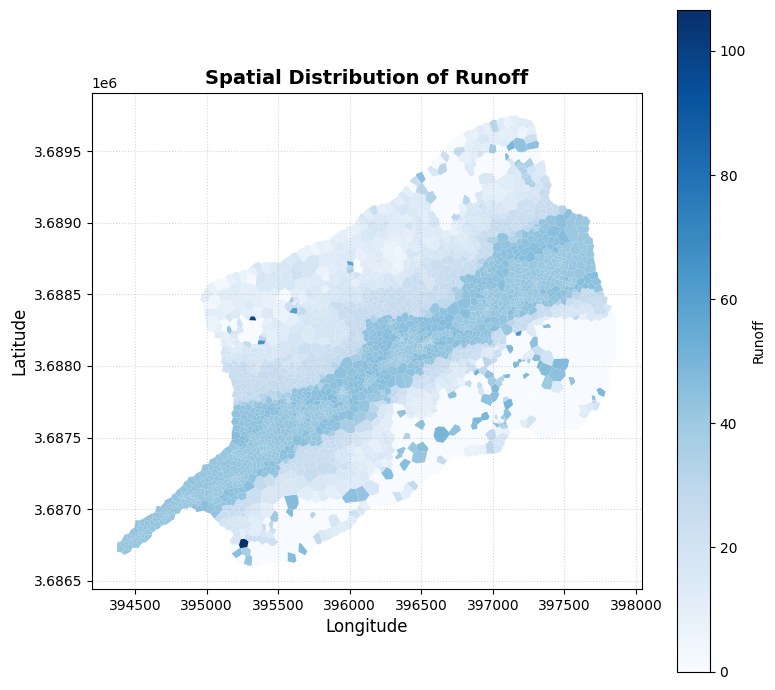

In [19]:
fig, ax = plt.subplots(figsize=(8, 7))

gdf.plot(ax=ax, column='HRt', cmap='Blues', legend=True,
         edgecolor='none',
         legend_kwds={'label': 'Runoff', 'orientation': 'vertical'})

ax.set_title('Spatial Distribution of Runoff', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

In [20]:
print(list(gdf.columns))

['ID', 'geometry', 'BndCd', 'Z', 'VAr', 'CAr', 'Curv', 'EdgL', 'Slp', 'FWidth', 'Aspect', 'SV', 'LV', 'AvSM', 'AvRtM', 'HOccr', 'HRt', 'SbOccr', 'SbRt', 'POccr', 'PRt', 'SatOccr', 'SatRt', 'SoiSatOccr', 'RchDsch', 'AvET', 'EvpFrct', 'cET', 'cEsoil', 'cLHF', 'cMelt', 'cSHF', 'cPHF', 'cRLIn', 'cRLo', 'cRSIn', 'cGHF', 'cUErr', 'cHrsSun', 'cHrsSnow', 'persTime', 'peakWE', 'initTime', 'peakTime', 'cIntSub', 'cSnSub', 'cSnEvap', 'cIntUnl', 'AvCanStorParam', 'AvIntercCoeff', 'AvTF', 'AvCanFieldCap', 'AvDrainCoeff', 'AvDrainExpPar', 'AvLUAlb', 'AvVegHeight', 'AvOTCoeff', 'AvStomRes', 'AvVegFract', 'AvLeafAI', 'AvEvapThresh', 'AvTransThresh', 'Bedrock_Depth_mm', 'Ks', 'ThetaS', 'ThetaR', 'PoreSize', 'AirEBubPress', 'DecayF', 'SatAnRatio', 'UnsatAnRatio', 'Porosity', 'VolHeatCond', 'SoilHeatCap', 'SoilID', 'LandUseID', 'weight']
